# ADAML Workshop 4: Transformer and Transfer Learning

## 0. Study how the Transformer works
Go through this website and study the inner workings of the transformer model

https://www.datacamp.com/tutorial/building-a-transformer-with-py-torch?dc_referrer=https%3A%2F%2Fwww.google.com%2F

## 1. Test the model performance with the test set (2p)
Model performance testing is implemented after the training. I use both `.evaluate()` to get the accuracy with small test set, and then I also iterate through all test samples for total test accuracy. Confusion matrix is shown after that for the entire test set (last part of the notebook). 

## 2. Experiment with adding and training layers (3p)
*Try to get better accuracy than with just the trained classification head.*

I experimented both with adding new layers and unfreezing the last transformer layer. I noticed that adding new layers did not improve the model accuracy, it instead made it worse. There might have been some information loss or conflict with learning rates between training the classification head vs. the additional layers.

Unfreezing the last transformer layer improved the model significantly, pumping the accuracy from 54\% to 88\%. 

## 3. Experiment with different pre-trained models (2p)
I tried out different pre-trained models, like `roberta-base`, `bert-base-uncased` and `bert-large-uncased` but did not notice any significant improvement compared to the given pre-trained model. Instead, the models with other pre-trained models performed worse.

## 4. Comment the notebook clearly and report what architecture you used for the best results (1p)
The best results was achieved with model that:
- Did not use any additional layer
- Trained the last transformer layer
- Used 10000 train data samples for training
- Used batch size 8
- Used learning rate 2e-4

Import libraries

In [ ]:
!pip install evaluate
from datasets import load_dataset
from transformers import Trainer
from transformers import AutoTokenizer
from transformers import pipeline
from transformers import TrainingArguments
from transformers import DataCollatorWithPadding
from transformers import AutoModelForSequenceClassification
import numpy as np
import evaluate

from torch import nn
import torch
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
import torch
from transformers.modeling_outputs import SequenceClassifierOutput

import wandb
wandb.init(mode="disabled")

Loading the data set and defining test and train sets

In [ ]:
dataset = load_dataset("emotion")

pretrained_model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name)

def tokenize_function(row):
    return tokenizer(row["text"], truncation=True)

token_data = dataset.map(tokenize_function, batched=True)
token_data = token_data.remove_columns(["text"])
token_data = token_data.rename_column("label", "labels")
token_data.set_format("torch")

small_train = token_data["train"].shuffle(seed=42).select(range(10000))
small_test = token_data["test"].shuffle(seed=42).select(range(1000))
batch_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Calculate class weights to tackle the class inbalance

In [78]:
class_labels = np.array(small_train['labels'])
unique_classes = np.unique(class_labels)
class_weights = compute_class_weight('balanced', classes=unique_classes, y=class_labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

Add custom layers to the model (Task 2). Adding new layers didn't end up improving the accuracy for me, so I have not used this for the final model 

In [ ]:
class CustomDistilBERT(nn.Module):
    def __init__(self, base_model, num_labels, dropout_rate=0.3):
        super().__init__()
        self.distilbert = base_model.distilbert
        self.config = base_model.config 
        
        # Additional layers, multiple linear layers with GELU activations and dropout
        self.additional_layer = nn.Sequential(
            nn.Linear(768, 768),  
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(768, 512),  
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),  
            nn.GELU(),
            nn.Dropout(dropout_rate)
        )
        
        self.classifier = nn.Linear(256, num_labels)
    
    # Device property is needed
    @property
    def device(self):
        return next(self.parameters()).device
        
    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        outputs = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        hidden_state = outputs[0]
        
        pooled_output = hidden_state[:, 0]
        
        pooled_output = self.additional_layer(pooled_output)
        logits = self.classifier(pooled_output)
        
        return SequenceClassifierOutput(logits=logits)

In [ ]:
labels = dataset["train"].features["label"].num_classes
model = AutoModelForSequenceClassification.from_pretrained(pretrained_model_name, num_labels=labels)

# Uncomment to use the custom model, this however did not improve results
# model = CustomDistilBERT(model, num_labels=labels)

# Freeze all parameters first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze classifier AND last transformer layer
for name, param in model.named_parameters():
    if "classifier" in name or "pre_classifier" in name:
        param.requires_grad = True
    # Unfreeze last transformer layer -> This improves results a lot
    if "distilbert.transformer.layer.5" in name: 
        param.requires_grad = True

# Verify which parameters are trainable
print("Trainable parameters after freezing:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable parameters after freezing:
distilbert.transformer.layer.5.attention.q_lin.weight
distilbert.transformer.layer.5.attention.q_lin.bias
distilbert.transformer.layer.5.attention.k_lin.weight
distilbert.transformer.layer.5.attention.k_lin.bias
distilbert.transformer.layer.5.attention.v_lin.weight
distilbert.transformer.layer.5.attention.v_lin.bias
distilbert.transformer.layer.5.attention.out_lin.weight
distilbert.transformer.layer.5.attention.out_lin.bias
distilbert.transformer.layer.5.sa_layer_norm.weight
distilbert.transformer.layer.5.sa_layer_norm.bias
distilbert.transformer.layer.5.ffn.lin1.weight
distilbert.transformer.layer.5.ffn.lin1.bias
distilbert.transformer.layer.5.ffn.lin2.weight
distilbert.transformer.layer.5.ffn.lin2.bias
distilbert.transformer.layer.5.output_layer_norm.weight
distilbert.transformer.layer.5.output_layer_norm.bias
pre_classifier.weight
pre_classifier.bias
classifier.weight
classifier.bias


In [81]:
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

Define training parameters. Batch size $8$ and learning rate $2\cdot10^{-4}$ worked the best for training

In [82]:
model_name = "distilbert-base-finetuned"
training_args = TrainingArguments(
    output_dir=model_name,
    learning_rate=2e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    weight_decay=0.01,
    fp16=True,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=False
)

Custom trainer class for taking the weighted loss into account (this can't be directly added to `Transformer` class)

In [ ]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
    
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        
        if hasattr(outputs, 'logits'):
            logits = outputs.logits
        else:
            logits = outputs.get('logits')
        
        device = logits.device
        class_weights_on_device = self.class_weights.to(device) if self.class_weights is not None else None
        
        # Use weighted cross entropy loss
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_on_device)
        loss = loss_fct(logits.view(-1, logits.size(-1)), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

model_trainer = WeightedTrainer(
    class_weights=class_weights_tensor,
    model=model,
    args=training_args,
    train_dataset=small_train,
    eval_dataset=small_test,
    data_collator=batch_collator,
    compute_metrics=compute_metrics
)
model_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.749900,0.512620,0.859000
2,0.453100,0.480819,0.862000
3,0.358200,0.526708,0.859000
4,0.277900,0.537393,0.868000
5,0.243800,0.497458,0.890000
6,0.200300,0.586621,0.890000
7,0.168600,0.751284,0.891000
8,0.142200,0.690967,0.884000
9,0.093600,0.785724,0.883000
10,0.081600,0.826194,0.880000


TrainOutput(global_step=12500, training_loss=0.27693748657226563, metrics={'train_runtime': 395.017, 'train_samples_per_second': 253.154, 'train_steps_per_second': 31.644, 'total_flos': 1063089447113664.0, 'train_loss': 0.27693748657226563, 'epoch': 10.0})

Define classifier pipeline

In [84]:
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer)

Device set to use cuda:0


Model testing, accuracy and confusion matrix (Task 1)

In [85]:
model_trainer.evaluate()

{'eval_loss': 0.7512843608856201,
 'eval_accuracy': 0.891,
 'eval_runtime': 1.4442,
 'eval_samples_per_second': 692.427,
 'eval_steps_per_second': 86.553,
 'epoch': 10.0}

Test with the entire test set

In [86]:
N_test = len(dataset["test"]["text"])

y_true = []
y_pred = []
correct = 0

for i in range(N_test):
    text = dataset["test"]["text"][i]
    true_label = dataset["test"]["label"][i]
    prediction = classifier(text)[0]
    predicted_label = dataset["train"].features["label"].str2int(prediction['label'].split('_')[-1])
    
    if predicted_label == true_label:
        correct += 1

    y_true.append(true_label)
    y_pred.append(predicted_label)


print(f"Accuracy: {correct/N_test:.4f}")

Accuracy: 0.8975


Plot confusion matrix

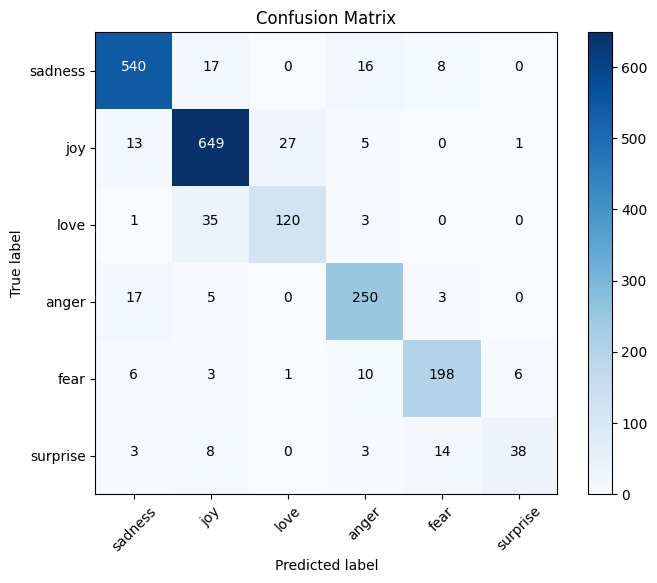

In [87]:
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(labels)
plt.xticks(tick_marks, dataset["train"].features["label"].names, rotation=45)
plt.yticks(tick_marks, dataset["train"].features["label"].names)
plt.texts = []
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j], horizontalalignment="center", color="white" if conf_matrix[i, j] > conf_matrix.max() / 2 else "black")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()